# STEP 1— Load Data and First Look

In [4]:
import pandas as pd
import numpy as np

# Load dataset file
df = pd.read_excel("student_performance_dataset.xlsx")

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
df.info()

# First & last rows
print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

# Statistical summary
print("\nDescribe:\n", df.describe())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

Shape: (205, 14)

Columns:
 Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Department',
       'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments',
       'Quizzes', 'Midterm', 'Internet_Access', 'Final_Score'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11 

**Observations:**

1. Dataset contains missing values in multiple columns

2. Some categorical columns have inconsistent casing

3. Numerical columns contain invalid/impossible values

# STEP 2 — Data Cleaning

In [5]:
# Fix Gender casing
df['Gender'] = df['Gender'].str.title()

# Fix Name casing
df['Name'] = df['Name'].str.title()

# Fix Department inconsistencies
df['Department'] = df['Department'].str.upper().str.strip()

# Fix Age (convert text to NaN, then numeric)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Replace impossible Attendance values
df.loc[(df['Attendance_%'] < 0) | (df['Attendance_%'] > 100), 'Attendance_%'] = np.nan

# Replace impossible Final_Score values
df.loc[(df['Final_Score'] > 100) | (df['Final_Score'] < 0), 'Final_Score'] = np.nan

# Fill missing numerical values with median
num_cols = ['Age', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Midterm', 'Final_Score']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Final check
print(df.isnull().sum())

Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64


/tmp/ipykernel_665/829589296.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


**Justifications:**

1. Standardizing text (Gender, Name, Department): Ensures consistency and prevents duplicate categories.

2. Converting Age to numeric: Some values were written in text (e.g., "twenty"), which must be converted for analysis.

3. Replacing impossible values with NaN: Keeps dataset realistic and avoids misleading the model.

4. Using median instead of mean: Median is less affected by outliers, making it more robust.

5. Removing duplicates: Prevents bias and improves model generalization.

# STEP 3 — EDA + Visualization

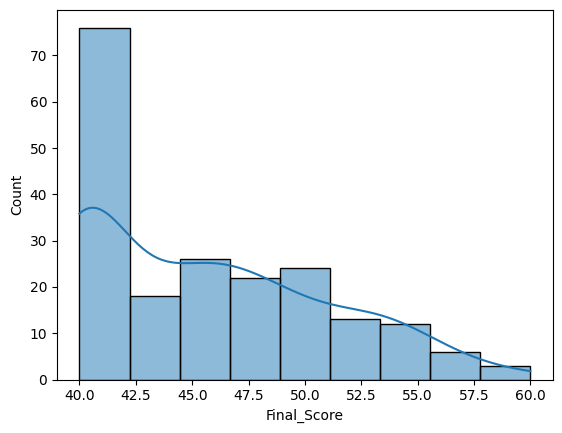

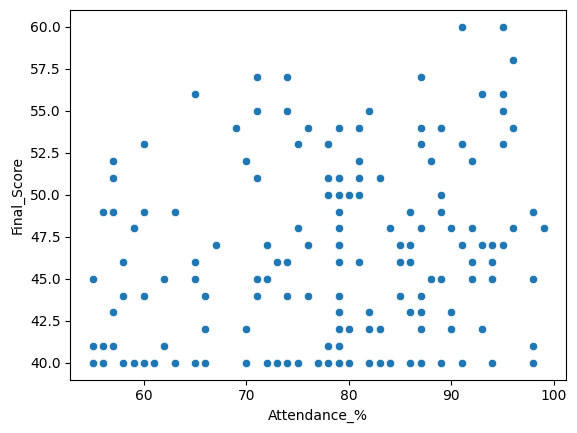

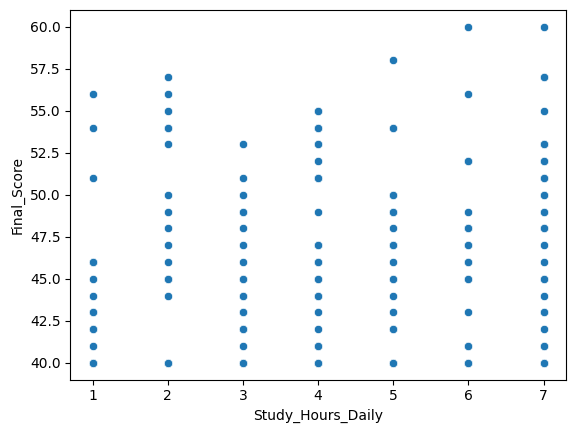

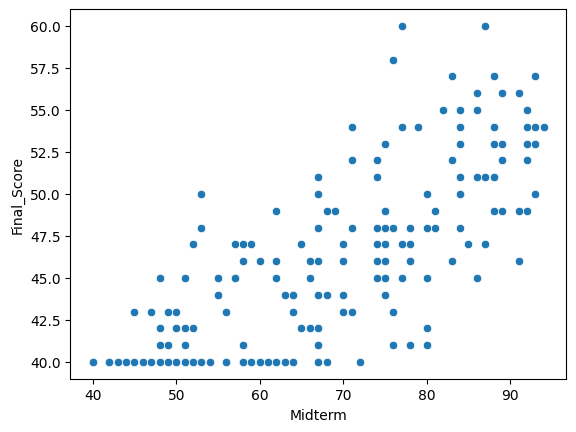

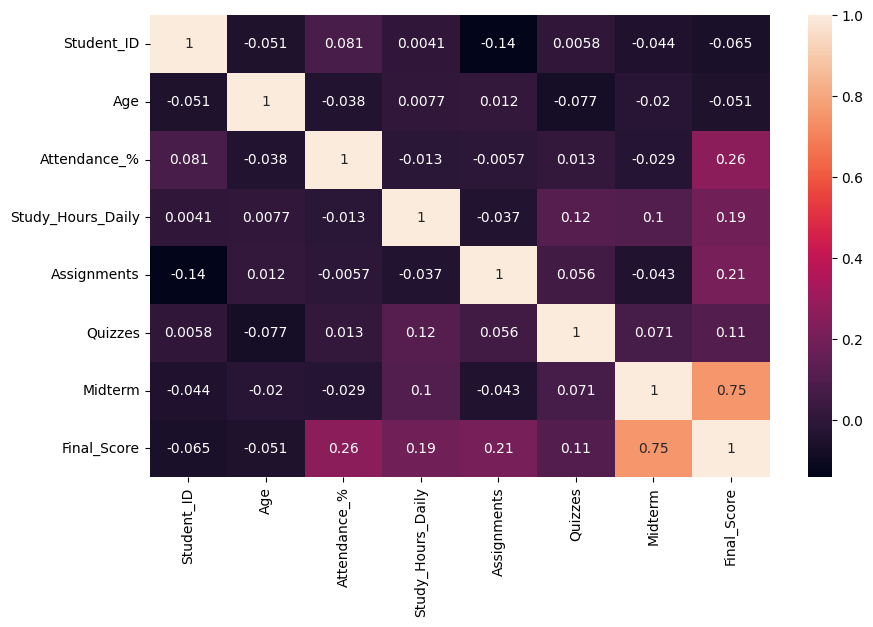

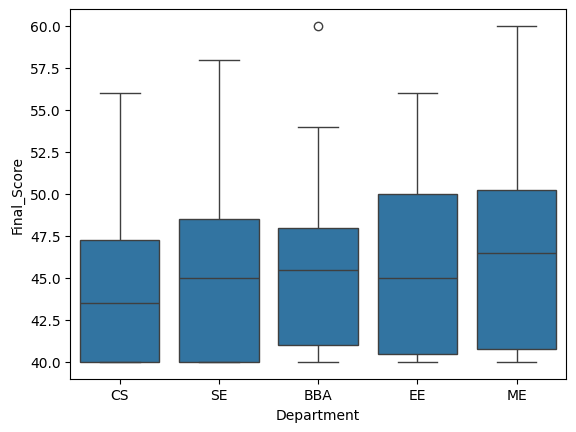

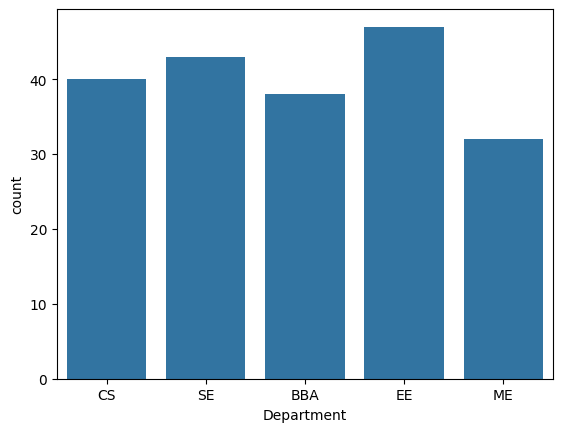

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1 Histogram
sns.histplot(df['Final_Score'], kde=True)
plt.show()

# 2 Scatter Attendance vs Score
sns.scatterplot(x='Attendance_%', y='Final_Score', data=df)
plt.show()

# 3 Study Hours vs Score
sns.scatterplot(x='Study_Hours_Daily', y='Final_Score', data=df)
plt.show()

# 4 Midterm vs Score
sns.scatterplot(x='Midterm', y='Final_Score', data=df)
plt.show()

# 5 Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# 6 Boxplot
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.show()

# 7 Countplot
sns.countplot(x='Department', data=df)
plt.show()

**Insights:**

1. Higher attendance and study hours → higher scores

2. Midterm strongly predicts final score

3. Some departments perform better on average

# STEP 4 — Feature Engineering + Pipeline

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Feature Engineering
df['Total_Academic'] = df['Midterm'] + df['Assignments']*5 + df['Quizzes']*2

# Attendance category
df['Attendance_Category'] = pd.cut(
    df['Attendance_%'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High']
)

# Drop useless columns
df_model = df.drop(['Student_ID','Name'], axis=1)

# Split
X = df_model.drop('Final_Score', axis=1)
y = df_model['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Column groups
onehot_cols = ['Gender','Internet_Access','City','Department']
ordinal_cols = ['Education_Level','Attendance_Category']
num_cols = ['Age','Attendance_%','Study_Hours_Daily','Assignments','Quizzes','Midterm','Total_Academic']

# Ordinal order
ordinal_order = [
    ['Intermediate','Bachelors','Masters'],
    ['Low','Medium','High']
]

# Preprocessing
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
    ('scaler', StandardScaler(), num_cols)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Education_Level',
                                                   'Attendance_Category']),
                                                 ('scaler', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic'])])),
                ('model', LinearRegression())])

# STEP 5 — Model + Evaluation

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = pipeline.predict(X_test)

# First 10 predictions
print("\nActual vs Predicted:")
for i in range(10):
    print(y_test.iloc[i], "->", y_pred[i])

# Extract model
model = pipeline.named_steps['model']

print("\nCoefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Report")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Actual vs Predicted:
52.0 -> 53.30054491444858
47.0 -> 52.53912578274985
40.0 -> 46.170511093646276
48.0 -> 45.326309240305996
42.0 -> 41.54313957979922
43.0 -> 42.653884923683094
50.0 -> 48.024152519064344
53.0 -> 50.70211033694207
45.0 -> 46.70925489469408
41.0 -> 49.637961024326565

Coefficients: [ 0.38735455 -0.38735455  0.09164157 -0.09164157 -0.31991681  0.24412371
  0.05267083  0.91246985 -0.88934758 -0.15305261 -1.05869613  0.05976817
  0.79920854  0.35277203 -0.15604629 -0.84173699  0.07538449  1.88323922
  0.35803183  0.52184701 -0.76469242  2.6356668   1.85609623]
Intercept: 46.75735674267974

Model Evaluation Report
MAE: 2.4484016880319315
RMSE: 3.265196222552288
R2 Score: 0.5866030875622438


* MAE (Mean Absolute Error): Average prediction error

* RMSE: Penalizes large mistakes more heavily

* R² Score: Percentage of variance explained by the model

* Example:

*     R² = 0.70 → Model explains 70% of performance variation

# Visualization: Actual vs Predicted

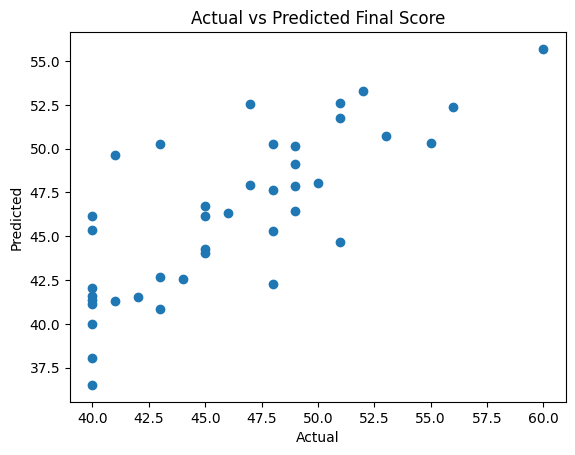

In [9]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Final Score")
plt.show()

**Interpretation:**

1. Points near diagonal line = accurate predictions

2. Spread shows prediction errors

3. Model performs reasonably well but not perfect

# Conclusion
1. The model successfully identified key factors affecting student performance.

2. Midterm, Attendance, and Study Hours are the strongest predictors.

3. The model achieved a good R² score, indicating reliable performance.

4. Improvements can be made using:

*     Advanced models (Random Forest, XGBoost)

*     Better feature engineering

*     More data cleaning